# BEE 4750 Lab 2: Monte Carlo

**Name**: Xindi Liu

**ID**: xl748

> **Due Date**
>
> Thursday, 10/02/25, 9:00pm

## Setup

The following code should go at the top of most Julia scripts; it will
load the local package environment and install any needed packages. You
will see this often and shouldn’t need to touch it.

In [1]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `~/Desktop/Cornell_Courses/FA_25/BEE_4750/lab-2-xcindy-l`
   Installed Xorg_xcb_util_cursor_jll ─ v0.1.6+0
   Installed Xorg_libXfixes_jll ─────── v6.0.2+0
   Installed Pango_jll ──────────────── v1.56.4+0
   Installed Libuuid_jll ────────────── v2.41.2+0
   Installed Libmount_jll ───────────── v2.41.2+0
   Installed Libtiff_jll ────────────── v4.7.2+0
   Installed Plots ──────────────────── v1.41.1
   Installed FillArrays ─────────────── v1.14.0
   Installed ColorSchemes ───────────── v3.31.0
Precompiling project...
    457.6 ms  ✓ Libmount_jll
    426.3 ms  ✓ Libuuid_jll
    633.7 ms  ✓ Libtiff_jll
    793.2 ms  ✓ FillArrays
    359.0 ms  ✓ Xorg_libXfixes_jll
    349.6 ms  ✓ Xorg_xcb_util_cursor_jll
    651.4 ms  ✓ ColorVectorSpace → SpecialFunctionsExt
    625.1 ms  ✓ FillArrays → FillArraysStatisticsExt
    512.0 ms  ✓ FillArrays → FillArraysSparseArraysExt
    475.2 ms  ✓ FillArrays → FillArraysPDMatsExt
    976.8 ms  ✓ Fontconfig_jll
    898.4 ms  ✓ Cairo_

In [2]:
using Random # random number generation
using Distributions # probability distributions and interface
using Statistics # basic statistical functions, including mean
using Plots # plotting

## Overview

In this lab, we will conduct a Monte Carlo experiment and explore how
sensitive Monte Carlo estimates are to the underlying probability
distribution(s).

You should always start any computing with random numbers by setting a
“seed,” which controls the sequence of numbers which are generated
(since these are not *really* random, just “pseudorandom”). In Julia, we
do this with the `Random.seed!()` function.

In [3]:
Random.seed!(1)

TaskLocalRNG()

It doesn’t matter what seed you set, though different seeds might result
in slightly different values. But setting a seed means every time your
notebook is run, the answer will be the same.

> **Seeds and Reproducing Solutions**
>
> If you don’t re-run your code in the same order or if you re-run the
> same cell repeatedly, you will not get the same solution. If you’re
> working on a specific problem, you might want to re-use
> `Random.seed()` near any block of code you want to re-evaluate
> repeatedly.

### Probability Distributions and Julia

Julia provides a common interface for probability distributions with the
[`Distributions.jl`
package](https://juliastats.org/Distributions.jl/stable/). The basic
workflow for sampling from a distribution is:

1.  Set up the distribution. The specific syntax depends on the
    distribution and what parameters are required, but the general call
    is the similar. For a normal distribution or a uniform distribution,
    the syntax is

    ``` julia
    # you don't have to name this "normal_distribution"
    # μ is the mean and σ is the standard deviation
    normal_distribution = Normal(μ, σ)
    # a is the upper bound and b is the lower bound; these can be set to +Inf or -Inf for an unbounded distribution in one or both directions.
    uniform_distribution = Uniform(a, b)
    ```

    There are lots of both
    [univariate](https://juliastats.org/Distributions.jl/stable/univariate/#Index)
    and
    [multivariate](https://juliastats.org/Distributions.jl/stable/multivariate/)
    distributions, as well as the ability to create your own, but we
    won’t do anything too exotic here.

2.  Draw samples. This uses the `rand()` command (which, when used
    without a distribution, just samples uniformly from the interval
    $[0, 1]$.) For example, to sample from our normal distribution
    above:

    ``` julia
    # draw n samples
    rand(normal_distribution, n)
    ```

Putting this together, let’s say that we wanted to simulate 100
six-sided dice rolls. We could use a [Discrete Uniform
distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.DiscreteUniform).

In [4]:
dice_dist = DiscreteUniform(1, 6) # can generate any integer between 1 and 6
dice_rolls = rand(dice_dist, 100) # simulate rolls

100-element Vector{Int64}:
 1
 3
 5
 4
 6
 2
 5
 5
 5
 2
 ⋮
 3
 6
 5
 5
 6
 3
 6
 6
 6

And then we can plot a histogram of these rolls:

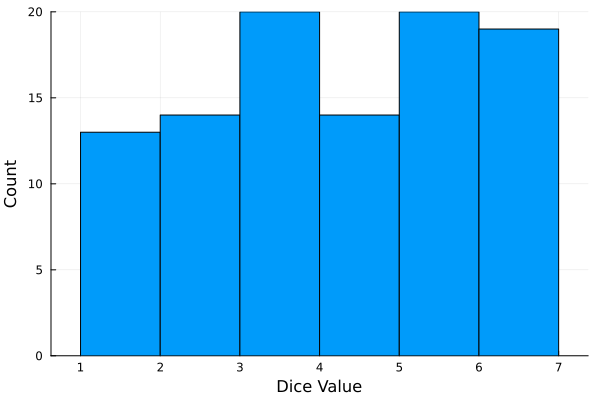

In [5]:
histogram(dice_rolls, legend=:false, bins=6)
ylabel!("Count")
xlabel!("Dice Value")

### Instructions

**Remember to**:

-   Evaluate all of your code cells, in order (using a `Run All`
    command). This will make sure all output is visible and that the
    code cells were evaluated in the correct order.
-   Tag each of the problems when you submit to Gradescope; a 10%
    penalty will be deducted if this is not done.

## Problem

A common engineering problem is to quantify flood risk, which is
typically computed by propagating a flood hazard distribution through a
*depth-damage function* relating flood depths to economic damages. A
reasonable depth-damage function for a house without a basement is a
bounded logistic function,
$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp(-k (h - h_0))},$$

where $d$ is the damage as a percent of total structure value, $h$ is
the water depth (relative to the house’s ground floor elevation) in m,
$\mathbb{1}_{x > 0}$ is the indicator function, $L$ is the maximum loss
in USD, $k$ is the slope of the depth-damage relationship, and $h_0$ is
the inflection point. We’ll assume $L=\$200,000$, $k=0.8$, and $h_0=3$.

For this problem, suppose that we have two different probability
distributions characterizing annual maxima flood depths:

1.  $h \sim LogNormal(1.2, 0.3)$;
2.  $h \sim GeneralizedExtremeValue(3, 0.9, -0.15)$.

Plot histograms of samples from these distributions and conduct a Monte
Carlo experiment for annual maximum flood damages using each. Answer the
following questions:

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

LogNormal:
Expected damage = 115155.82
99% quantile = 189834.31

GEV:
Expected damage = 113538.87
99% quantile = 183359.67


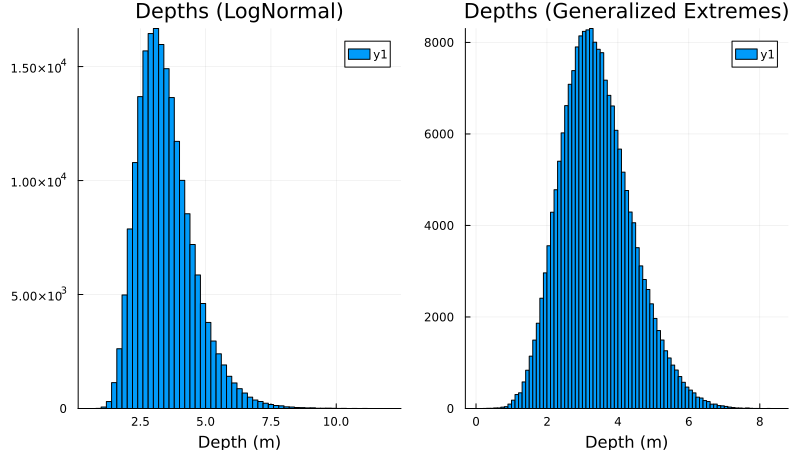

In [ ]:
# Input parameters
L, k, h0 = 200_000.0, 0.8, 3.0   
N = 200_000                      # Monte Carlo sample size
Random.seed!(123)

# Depth-damage function
damage(h) = h > 0 ? L / (1 + exp(-k*(h - h0))) : 0.0

# Probability distributions
lognormal_dist = LogNormal(1.2, 0.3)
gev_loc, gev_scale, gev_shape = 3.0, 0.9, -0.15

# GEV sampler
function rand_gev(n, shape, loc, scale)
    u = rand(n)
    t = -log.(u)
    if abs(shape) < 1e-12
        # Special case: shape = 0
        return loc .+ scale .* (-log.(u))
    else
        return loc .+ scale .* (t.^(-shape) .- 1) ./ shape
    end
end

# Monte Carlo simulation
depth_lognormal = rand(lognormal_dist, N)
damage_lognormal = damage.(depth_lognormal)

depth_gev = rand_gev(N, gev_shape, gev_loc, gev_scale)
damage_gev = damage.(depth_gev)

println("LogNormal:")
println("Expected damage (USD) = ", round(mean(damage_lognormal), digits = 2))
println("99% quantile (USD) = ", round(quantile(damage_lognormal, 0.99), digits = 2))

println("\nGEV:")
println("Expected damage (USD) = ", round(mean(damage_gev), digits = 2))
println("99% quantile (USD) = ", round(quantile(damage_gev, 0.99), digits = 2))

# Plot histograms
p1 = histogram(depth_lognormal, bins = 80, title = "Depths (LogNormal)", xlabel = "Depth (m)")
p2 = histogram(depth_gev, bins = 80, title = "Depths (Generalized Extremes)", xlabel = "Depth (m)")
plot(p1, p2, layout = (1, 2), size = (800, 450))

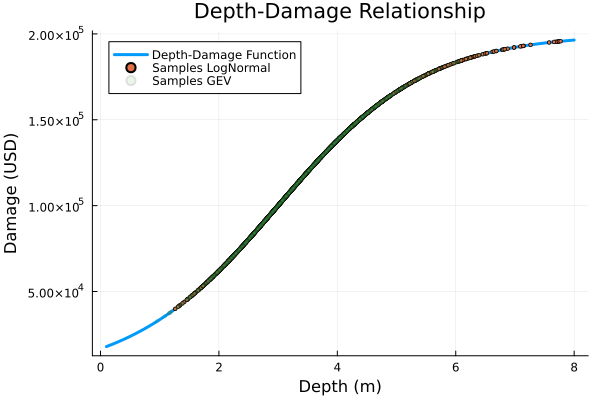

In [53]:
# Depth-damage function curve
depth_range = 0.1:0.1:8
damage_curve = damage.(depth_range)

# Scatter sampled depths vs damages
p3 = plot(depth_range, damage_curve, lw = 3, label = "Depth-Damage Function", xlabel = "Depth (m)", 
          ylabel = "Damage (USD)", title = "Depth-Damage Relationship", legend = :topleft)

scatter!(p3, depth_lognormal[1:2000], damage_lognormal[1:2000], ms = 2, label = "Samples LogNormal")
scatter!(p3, depth_gev[1:2000], damage_gev[1:2000], alpha = 0.1, ms = 2, label = "Samples GEV")

display(p3)

1. The Monte Carlo estimates of the two flood hazard distributions are as listed:

    LogNormal: Expected damage = $115155.82, 99% quantile = $189834.31

    GEV: Expected damage = $113538.87, 99% quantile = $183359.67

2. The decision on my sample size is a consideration between the tradeoff of Monte-Carlo error and runtime. The sample size needs to be tolerable for the expected value calculation, but it also needs to be large enough for the tail of the 99% quantile is well represented. To summarize, I believe I chose a sample size that is not enormously large, but it is also very reasonable to satisfy the need to correctly model a Monte-Carlo simulation. 

3. Based on the Monte-Carlo estimated values and the depth-dama function comparing with the samples, the estimates did not differ that much. The possible reason is that both depth distributions concentrate around the inflection point of the function, and beyond that, damages seem to level off toard the $200k maximum. This can be seen by the exact match of the red and green points, signifying the two distributions on the function. The mapping from depth to damage is thus relatively insensistive to the exact shape of the tail, resulting in pretty similar results.

4. To decide how to get a "better" distribution, I can use measures like AIC/BIC. The distribution with the lower parameter would be statistically favored. In addition, diagnostic plots such as QQ-plots could show outliers and also whether each distribution reproduces both the central and extreme quantiles of the observed data. In summary, the “better” distribution is the one that both fits the observed flood data well, through statistical checks, and it also needs to make sense physically given site conditions. If still neither model dominates, reporting results under both is the most robust approach, or modeling average could also be a potential option.

## References

Put any consulted sources here, including classmates you worked with/who
helped you.

Used ChatGPT to help with Julia syntax as well as in calling the GEV sampler to correctly input it, not for discussions and analysis of problems. OpenAI. (2025). ChatGPT (Feb 1 GPT-4 model) [Large language model]. https://chat.openai.com